# Demo: getting and adding contextual information to an STM

`depsi` only implements the **add** side -- attaching already-fetched data to an STM. Fetching contextual
data (the **get** side) is handled by a separate repo, not by `depsi` itself. This
notebook still includes one example of fetching real data via
[`get_weatherdata`](https://github.com/LinaHagenah/Get_WeatherData), at present it is a private GitHub repo. To execute the data fetching part, you need access to this repository and install from source.

Four cases, each adding attributes to the same synthetic base STM:

1. **Default enrichment (point)**: `incidence_angle` + `crossrange` (from the orbit) + `temperature`
   (fetched from ERA5, one station).
2. **Default + precipitation**: case 1's result, with `precipitation` (also fetched from ERA5, same
   station) added on top -- a second point-sourced attribute.
3. **Enrich from grid**: `temperature` from three synthetic stations spread across the area, built
   directly in this notebook (no fetching) -- `stmtools` does real nearest-neighbor spatial matching, so
   different STM points get different stations' values.
4. **Enrich from polygon**: a synthetic `land_use` polygon, also built directly in this notebook -- a
   static, point-in-polygon join instead of a nearest-neighbor time series match.

Cases 3 and 4 use synthetic data because they're demonstrating the enrichment *mechanism* (spatial
matching, polygon join), not real station/land-use data -- see
`docs/usages/add_contextual_information.md` for the full picture, including the config-driven form of
all three `add_contextual_information_from_*` functions.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
import geopandas as gpd
from shapely.geometry import box

from depsi.viewing_geometry import add_local_viewing_geometry, add_cross_range
from depsi.contextual_information import (
    add_contextual_information_from_point,
    add_contextual_information_from_grid,
    add_contextual_information_from_polygon,
)

## Illustration: fetching real data with `get_weatherdata`

In [2]:
from get_weatherdata import read_era5_data
import pandas as pd


def fetch_era5_to_csv(lat, lon, source_column, attribute_name, start_date, end_date, output_file):
    """Illustrative only, not part of depsi -- fetches one ERA5 column and writes it in the CSV shape
    `add_contextual_information_from_point`/`_from_grid` expect: a "Date" index column, one column named
    after the attribute. In the real workflow, this "get" step lives in a separate repo entirely; this
    function just shows where that CSV/dict data ends up coming from.
    """
    dates = [d.to_pydatetime() for d in pd.date_range(start_date, end_date)]
    raw = read_era5_data(lat, lon, dates, requested_columns=(source_column,), save_path=None)
    df = pd.DataFrame(
        {attribute_name: [values[source_column] for values in raw.values()]},
        index=pd.Index(raw.keys(), name="Date"),
    )
    df.to_csv(output_file)
    return df

## Base STM

25 points around central Amsterdam, inside Sentinel-1 track `s1_dsc_t037`, 8 dates on a ~12-day repeat
cycle. No explicit `space` coordinate -- `stmtools`' spatial matching (used by the grid case) only works
correctly that way.

In [3]:
rng = np.random.default_rng(0)

n_space = 25
n_time = 8

lat = 52.3676 + rng.uniform(-0.01, 0.01, n_space)
lon = 4.9041 + rng.uniform(-0.01, 0.01, n_space)
time = np.array(
    ["2026-07-01", "2026-07-13", "2026-07-25", "2026-08-06", "2026-08-10", "2026-08-14", "2026-08-19", "2026-08-24"],
    dtype="datetime64[ns]",
) + np.timedelta64(17 * 60 + 20, "m")  # ~17:20 UTC acquisition time, like Sentinel-1 over the Netherlands

sd_h2ph = rng.uniform(0.5, 1.5, (n_space, n_time))

stm = xr.Dataset(
    data_vars={"sd_h2ph": (["space", "time"], sd_h2ph)},
    coords={"lat": ("space", lat), "lon": ("space", lon), "time": time},
)
stm

<xarray.Dataset> Size: 2kB
Dimensions:  (space: 25, time: 8)
Coordinates:
    lat      (space) float64 200B 52.37 52.36 52.36 52.36 ... 52.37 52.37 52.37
    lon      (space) float64 200B 4.902 4.914 4.914 4.908 ... 4.907 4.896 4.911
  * time     (time) datetime64[ns] 64B 2026-07-01T17:20:00 ... 2026-08-24T17:...
Dimensions without coordinates: space
Data variables:
    sd_h2ph  (space, time) float64 2kB 1.287 0.7394 1.376 ... 1.414 0.5653 1.335

## 1. Default enrichment: incidence angle + crossrange + temperature

Real orbit computation (ASF search + orbit propagation, can take a minute or two) and a real ERA5 fetch.
Incidence angle and crossrange are viewing geometry, not contextual data -- they come from
`depsi.viewing_geometry`, not `depsi.contextual_information`: `add_local_viewing_geometry` computes
`local_incidence_angle`, then `add_cross_range` computes `sd_cr2ph` from that plus `sd_h2ph`.

In [4]:
import depsi
from pathlib import Path

orbit_cfg_file = str(Path(depsi.__file__).resolve().parent.parent / "config" / "drama" / "S1_XTI.cfg")

stm_case1 = add_local_viewing_geometry(
    stm,
    orbit_config_file=orbit_cfg_file,
    orbit_res=0.01,
    orbit_mode="IWS",
    orbit="s1_dsc_t037",
)
stm_case1 = add_cross_range(stm_case1)

fetch_era5_to_csv(
    lat=52.3676,
    lon=4.9041,
    source_column="temperature_2m_mean",
    attribute_name="temperature",
    start_date="2026-07-01",
    end_date="2026-08-24",
    output_file="/tmp/depsi_demo_temperature.csv",
)

stm_case1 = add_contextual_information_from_point(
    stm_case1,
    selected_attributes=["temperature"],
    attribute_sources={"temperature": (52.3676, 4.9041, "/tmp/depsi_demo_temperature.csv")},
)
list(stm_case1.data_vars)

['sd_h2ph',
 'local_incidence_angle',
 'local_azimuth_angle',
 'sd_cr2ph',
 'temperature']

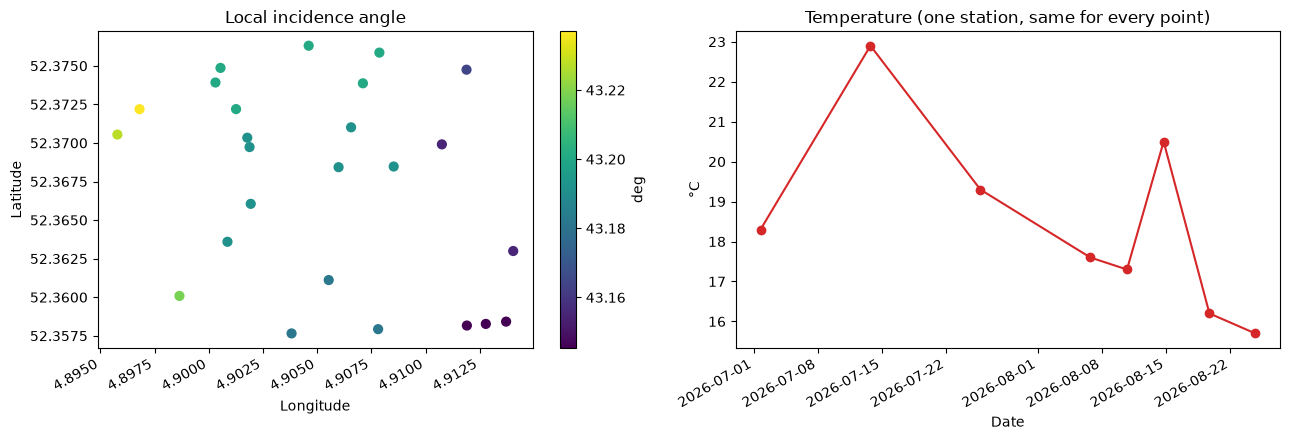

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sc = axes[0].scatter(
    stm_case1["lon"].values, stm_case1["lat"].values,
    c=stm_case1["local_incidence_angle"].values, cmap="viridis", s=40,
)
axes[0].set_xlabel("Longitude")
axes[0].set_ylabel("Latitude")
axes[0].set_title("Local incidence angle")
fig.colorbar(sc, ax=axes[0], label="deg")

axes[1].plot(stm_case1["time"].values, stm_case1["temperature"].values[0], marker="o", color="tab:red")
axes[1].set_xlabel("Date")
axes[1].set_ylabel("\u00b0C")
axes[1].set_title("Temperature (one station, same for every point)")
fig.autofmt_xdate()
fig.tight_layout()

## 2. Default + precipitation from ERA5

Builds on case 1's `stm_case1` (already has `incidence_angle`/`crossrange`/`temperature`) and adds a
second point-sourced attribute, `precipitation`, fetched from the same station.

In [6]:
fetch_era5_to_csv(
    lat=52.3676,
    lon=4.9041,
    source_column="precipitation_sum",
    attribute_name="precipitation",
    start_date="2026-07-01",
    end_date="2026-08-24",
    output_file="/tmp/depsi_demo_precipitation.csv",
)

stm_case2 = add_contextual_information_from_point(
    stm_case1,
    selected_attributes=["precipitation"],
    attribute_sources={"precipitation": (52.3676, 4.9041, "/tmp/depsi_demo_precipitation.csv")},
)
list(stm_case2.data_vars)

['sd_h2ph',
 'local_incidence_angle',
 'local_azimuth_angle',
 'sd_cr2ph',
 'temperature',
 'precipitation']

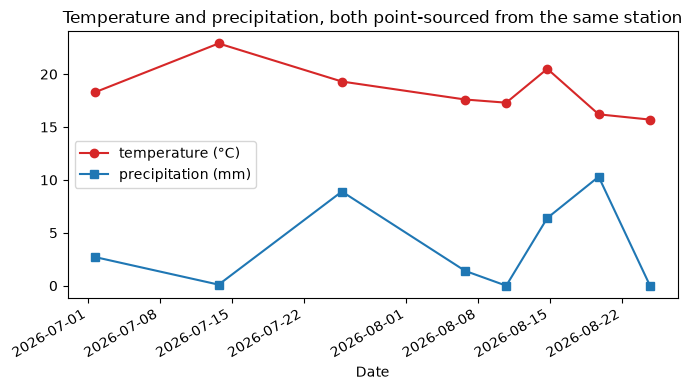

In [7]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(stm_case2["time"].values, stm_case2["temperature"].values[0], marker="o", color="tab:red", label="temperature (\u00b0C)")
ax.plot(stm_case2["time"].values, stm_case2["precipitation"].values[0], marker="s", color="tab:blue", label="precipitation (mm)")
ax.set_xlabel("Date")
ax.set_title("Temperature and precipitation, both point-sourced from the same station")
ax.legend()
fig.autofmt_xdate()
fig.tight_layout()

## 3. Enrich from grid: temperature from three synthetic stations

Three stations spread across the area (north/center/south), each with its own synthetic temperature
series -- `center` is deliberately missing one date, to show the NaN reindexing
`add_contextual_information_from_grid` does when locations don't share the same date coverage. No
fetching -- built directly as dicts here.

In [8]:
station_data = {
    "north": (52.376, 4.900, {
        "2026-07-01": {"temperature": 14.0}, "2026-07-13": {"temperature": 15.5},
        "2026-07-25": {"temperature": 16.0}, "2026-08-06": {"temperature": 15.0},
        "2026-08-10": {"temperature": 14.5}, "2026-08-14": {"temperature": 14.0},
        "2026-08-19": {"temperature": 13.0}, "2026-08-24": {"temperature": 12.5},
    }),
    "center": (52.3676, 4.9041, {
        "2026-07-01": {"temperature": 18.0}, "2026-07-13": {"temperature": 20.0},
        "2026-07-25": {"temperature": 21.0}, "2026-08-06": {"temperature": 19.0},
        "2026-08-10": {"temperature": 18.5}, "2026-08-14": {"temperature": 18.0},
        # 2026-08-19 deliberately missing here
        "2026-08-24": {"temperature": 16.0},
    }),
    "south": (52.358, 4.910, {
        "2026-07-01": {"temperature": 22.0}, "2026-07-13": {"temperature": 24.0},
        "2026-07-25": {"temperature": 25.0}, "2026-08-06": {"temperature": 23.0},
        "2026-08-10": {"temperature": 22.5}, "2026-08-14": {"temperature": 22.0},
        "2026-08-19": {"temperature": 20.0}, "2026-08-24": {"temperature": 19.0},
    }),
}

stm_grid = add_contextual_information_from_grid(
    stm,
    selected_attributes=["temperature"],
    attribute_sources={"temperature": list(station_data.values())},
)
list(stm_grid.data_vars)

['sd_h2ph', 'temperature']

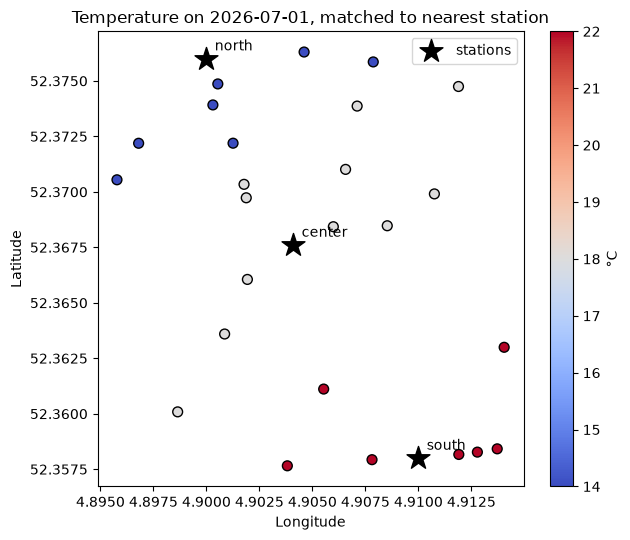

In [9]:
fig, ax = plt.subplots(figsize=(6.5, 5.5))
sc = ax.scatter(
    stm_grid["lon"].values, stm_grid["lat"].values,
    c=stm_grid["temperature"].values[:, 0], cmap="coolwarm", s=50, edgecolor="k", zorder=2,
)
station_lats = [lat for lat, _, _ in station_data.values()]
station_lons = [lon for _, lon, _ in station_data.values()]
ax.scatter(station_lons, station_lats, marker="*", s=300, c="black", zorder=3, label="stations")
for name, (lat, lon, _) in station_data.items():
    ax.annotate(name, (lon, lat), textcoords="offset points", xytext=(6, 6))
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title(f"Temperature on {str(stm_grid['time'].values[0])[:10]}, matched to nearest station")
fig.colorbar(sc, ax=ax, label="\u00b0C")
ax.legend()
fig.tight_layout()

## 4. Enrich from polygon: synthetic land use

Two polygons -- `urban` covering the western half of the area, `green_space` covering the northeastern
quarter -- leaving the southeastern quarter uncovered, to show that points outside every polygon get
`None`. `enrich_from_polygon` needs `stm` to be dask-backed, hence `.chunk(...)` below.

In [10]:
land_use_polygons = gpd.GeoDataFrame(
    {"land_use": ["urban", "green_space"]},
    geometry=[
        box(4.894, 52.357, 4.904, 52.378),
        box(4.904, 52.367, 4.914, 52.378),
    ],
    crs="EPSG:4326",
)

stm_polygon = add_contextual_information_from_polygon(
    stm.chunk({"space": -1, "time": -1}),
    selected_attributes=["land_use"],
    attribute_sources={"land_use": (land_use_polygons, "land_use")},
)
list(stm_polygon.data_vars)

['sd_h2ph', 'land_use']

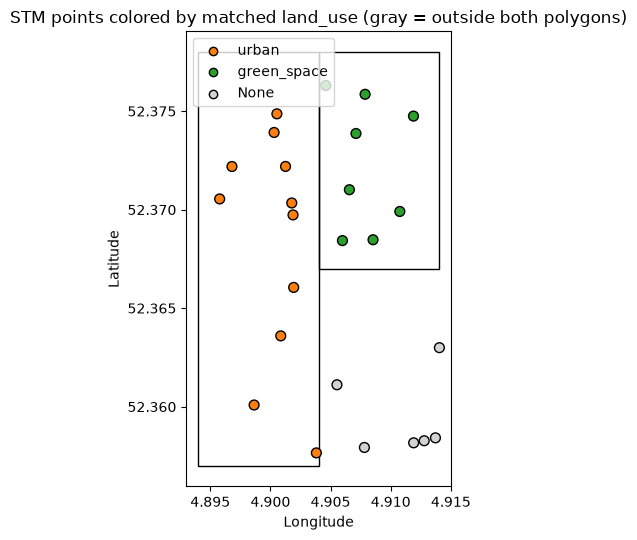

In [11]:
fig, ax = plt.subplots(figsize=(6.5, 5.5))
color_by_land_use = {"urban": "tab:orange", "green_space": "tab:green", None: "lightgray"}
land_use_values = stm_polygon["land_use"].values
colors = [color_by_land_use[value] for value in land_use_values]

land_use_polygons.boundary.plot(ax=ax, color="black", linewidth=1, zorder=1)
ax.scatter(stm_polygon["lon"].values, stm_polygon["lat"].values, c=colors, s=50, edgecolor="k", zorder=2)
for label, color in color_by_land_use.items():
    ax.scatter([], [], c=color, edgecolor="k", label=str(label))
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("STM points colored by matched land_use (gray = outside both polygons)")
ax.legend()
fig.tight_layout()

## 5. Combining point, grid, and polygon in one script

There's no dedicated "dispatch by kind" function in `depsi` -- each `add_contextual_information_from_*`
function is called directly for whichever attributes it applies to. This reuses data already built above:
`temperature` (point, case 1's CSV), `grid_temperature` (grid, case 3's synthetic stations), and `land_use`
(polygon, case 4's synthetic polygons).

In [12]:
attribute_sources_by_kind = {
    "point": {"temperature": (52.3676, 4.9041, "/tmp/depsi_demo_temperature.csv")},
    "grid": {
        "grid_temperature": [
            (lat, lon, {date: {"grid_temperature": value["temperature"]} for date, value in data.items()})
            for lat, lon, data in station_data.values()
        ]
    },
    "polygon": {"land_use": (land_use_polygons, "land_use")},
}

stm_combined = stm.chunk({"space": -1, "time": -1})  # required for the polygon step

for kind, sources in attribute_sources_by_kind.items():
    names = list(sources.keys())
    if kind == "point":
        stm_combined = add_contextual_information_from_point(stm_combined, names, sources)
    elif kind == "grid":
        stm_combined = add_contextual_information_from_grid(stm_combined, names, sources)
    elif kind == "polygon":
        stm_combined = add_contextual_information_from_polygon(stm_combined, names, sources)

list(stm_combined.data_vars)

['sd_h2ph', 'temperature', 'grid_temperature', 'land_use']